In [49]:
import pandas as pd
from pathlib import Path

# Run with cwd = thesis repo root, or from 04_SentimentAnalysis (then we go up one level).
root = Path.cwd()
if root.name == "04_SentimentAnalysis":
    root = root.parent

df_topic_assignments = pd.read_csv(root / "02_TopicModeling/outputs/03_new_topic_assignments.csv")
df = pd.read_csv(root / "04_SentimentAnalysis/outputs/emotion_fulltext_resultsv2.csv")

_manual = ["Manual Topic Label", "Manual Cluster Label"]
df = df.merge(
    df_topic_assignments[["row_id", *_manual]].drop_duplicates("row_id"),
    on="row_id",
    how="left",
)

anger_col = "emotion_anger"
df[anger_col] = pd.to_numeric(df[anger_col], errors="coerce")
fear_col = "emotion_fear"
df[fear_col] = pd.to_numeric(df[fear_col], errors="coerce")


In [50]:
df['Manual Cluster Label'].value_counts()

Manual Cluster Label
German Party Politics                        2267
Russia (-Ukraine) Diplomacy & Sanctions      2038
Miscellaneous                                1748
US & Transatlantic Politics                  1747
Russia-Ukraine War                           1305
Middle East                                  1303
German Economy & Industry                    1293
Social Policy & Welfare                      1260
International Affairs                         995
Energy, Climate & Environment                 950
Justice System & Political Conflict           934
Migration & Internal Security                 775
Free Speech, Crime & Political Repression     762
Media & Information Ecosystem                 639
Finance & Markets                             551
German Military & Defense                     437
Identity & Culture War                        426
Health & COVID-19                             378
Name: count, dtype: int64

### Save df as csv for further use

In [ ]:
#df.to_csv(root / "04_SentimentAnalysis/outputs/emotion_fulltext_with_topiclabels.csv", index=False)

### Domestic vs. international topic overall

anger

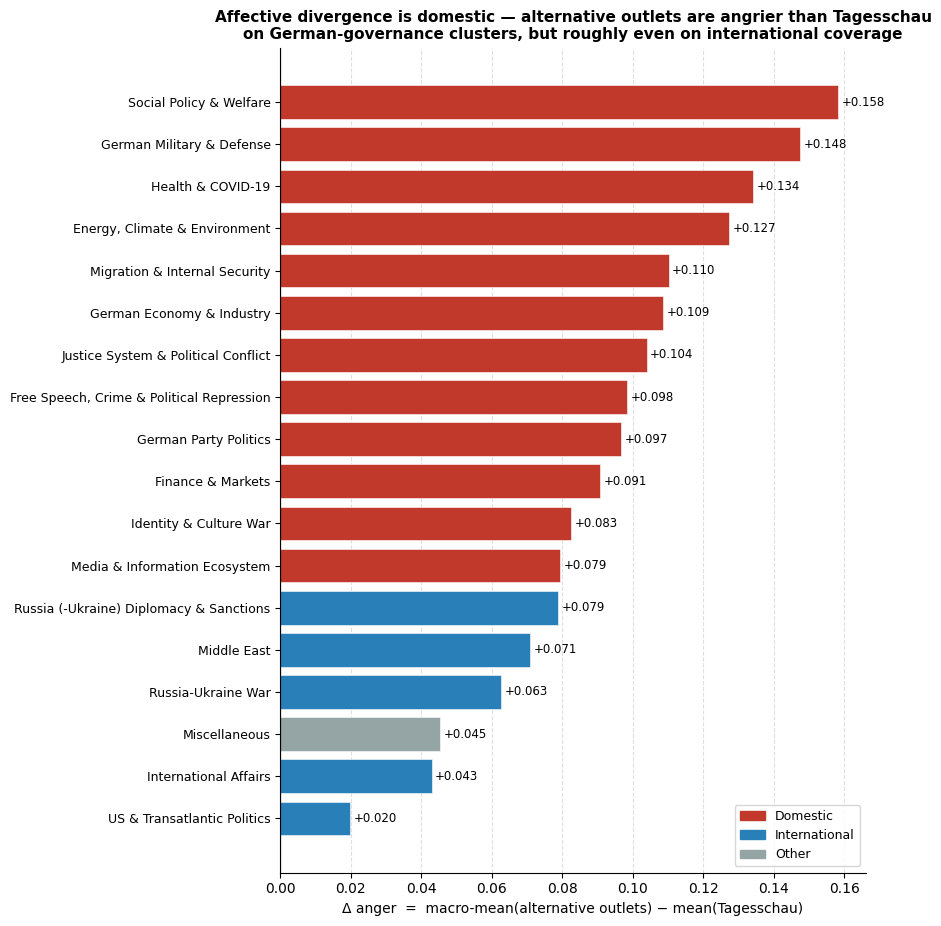

In [52]:
# ── Δ anger per cluster: mean(alternative outlets) − mean(Tagesschau) ────────
# Bars coloured by topic geography: Domestic / International / Other
# Alternative-outlet side uses macro-mean (avg of per-outlet means) to avoid
# size-imbalance bias across outlets.

import numpy as np
from matplotlib.patches import Patch
import pandas as pd
import matplotlib.pyplot as plt

DOMESTIC = {
    "Social Policy & Welfare",
    "Health & COVID-19",
    "Energy, Climate & Environment",
    "German Economy & Industry",
    "Migration & Internal Security",
    "German Party Politics",
    "Free Speech, Crime & Political Repression",
    "Media & Information Ecosystem",
    "Justice System & Political Conflict",
    "Identity & Culture War",
    "Finance & Markets",
    "German Military & Defense",
}
INTERNATIONAL = {
    "Middle East",
    "Russia (-Ukraine) Diplomacy & Sanctions",
    "US & Transatlantic Politics",
    "Russia-Ukraine War",
    "International Affairs",
}

GEO_COLOR = {"Domestic": "#c0392b", "International": "#2980b9", "Other": "#95a5a6"}

def _geo(cluster):
    if cluster in DOMESTIC:      return "Domestic"
    if cluster in INTERNATIONAL: return "International"
    return "Other"

min_n = 10

tg  = df[df["source"] == "Tagesschau"]
alt = df[df["source"] != "Tagesschau"]

# Tagesschau: grand mean per cluster
tg_means = tg.groupby("Manual Cluster Label")[anger_col].mean()

# Alternative outlets: macro-mean (avg of per-outlet means per cluster)
alt_macro = (
    alt.groupby(["Manual Cluster Label", "source"])[anger_col]
    .mean()
    .groupby("Manual Cluster Label")
    .mean()
)

# Keep clusters with enough articles in BOTH groups
tg_n  = tg.groupby("Manual Cluster Label").size()
alt_n = alt.groupby("Manual Cluster Label").size()
keep  = tg_n.index.intersection(alt_n.index).intersection(alt_macro.index)
keep  = keep[(tg_n[keep] >= min_n) & (alt_n[keep] >= min_n)]

delta = (alt_macro[keep] - tg_means[keep]).sort_values(ascending=True)

colors = [GEO_COLOR[_geo(c)] for c in delta.index]

fig, ax = plt.subplots(figsize=(9, max(5, len(delta) * 0.52)))

bars = ax.barh(delta.index, delta.values, color=colors, edgecolor="white", linewidth=0.4)

for bar, val in zip(bars, delta.values):
    sign  = "+" if val >= 0 else ""
    x_pos = val + (0.001 if val >= 0 else -0.001)
    ha    = "left" if val >= 0 else "right"
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f"{sign}{val:.3f}", va="center", ha=ha, fontsize=8.5)

ax.axvline(0, color="black", linewidth=0.8)
ax.xaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.set_xlabel("Δ anger  =  macro-mean(alternative outlets) − mean(Tagesschau)", fontsize=10)
ax.set_title(
    "Affective divergence is domestic — alternative outlets are angrier than Tagesschau\n"
    "on German-governance clusters, but roughly even on international coverage",
    fontsize=11, fontweight="bold",
)
ax.tick_params(axis="y", labelsize=9)
ax.spines[["top", "right"]].set_visible(False)

legend_handles = [Patch(color=c, label=l) for l, c in GEO_COLOR.items()]
ax.legend(handles=legend_handles, loc="lower right", frameon=True, fontsize=9)

plt.tight_layout()
plt.show()


In [53]:
# ── Summary: Δ anger domestic vs international — alternative outlets vs Tagesschau
# Uses DOMESTIC / INTERNATIONAL sets defined in the cell above.

def _geo(cluster):
    if cluster in DOMESTIC:      return "Domestic"
    if cluster in INTERNATIONAL: return "International"
    return "Other"

df["geo"] = df["Manual Cluster Label"].map(_geo)

tg  = df[df["source"] == "Tagesschau"]
alt = df[df["source"] != "Tagesschau"]

results = {}
for geo in ("Domestic", "International"):
    tg_mean  = tg[tg["geo"]  == geo][anger_col].mean()
    # macro-mean: average of per-outlet means (corrects for outlet size)
    alt_macro = (
        alt[alt["geo"] == geo]
        .groupby("source")[anger_col].mean()
        .mean()
    )
    delta = alt_macro - tg_mean
    results[geo] = {"Tagesschau": tg_mean, "Alt (macro)": alt_macro, "Δ": delta}
    print(f"{geo:15s}  →  Tagesschau: {tg_mean:.4f}  |  Alt outlets: {alt_macro:.4f}  |  Δ = {delta:+.4f}")


Domestic         →  Tagesschau: 0.6652  |  Alt outlets: 0.7881  |  Δ = +0.1229
International    →  Tagesschau: 0.6871  |  Alt outlets: 0.7367  |  Δ = +0.0497


Outlet                    Δ_dom sig_dom   Δ_intl sig_intl  diff (dom−intl)
---------------------------------------------------------------------------
Deutschlandkurier       +0.1153***   +0.0261***           +0.0892
Antispiegel             +0.1364***   +0.0520***           +0.0844
RT_de                   +0.0395***   -0.0425              +0.0820
Tichys_Einblick         +0.1917***   +0.1173***           +0.0744
Nius                    +0.1122***   +0.0477***           +0.0645
Compact                 +0.1423***   +0.0974***           +0.0449


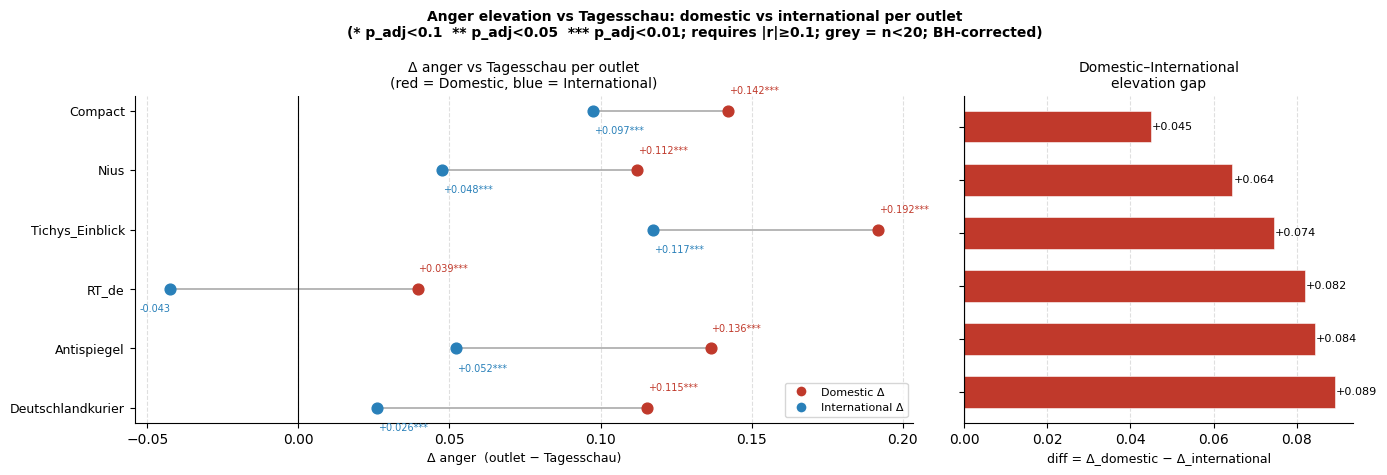

In [54]:
# ── Per-outlet: domestic vs international elevation gap vs Tagesschau (anger) ─────
# For each outlet: Δ_domestic and Δ_international (vs Tagesschau), tested with MWU + BH.
# Key metric: diff = Δ_domestic − Δ_international
#   positive → outlet elevates anger MORE on domestic than on international topics

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import numpy as np

MIN_N        = 20
EFFECT_R_MIN = 0.10

df["geo"] = df["Manual Cluster Label"].map(_geo)
tg_all  = df[df["source"] == "Tagesschau"]
outlets = sorted(df[df["source"] != "Tagesschau"]["source"].unique())

records = []
for geo in ("Domestic", "International"):
    tg_vals = tg_all[tg_all["geo"] == geo][anger_col].values
    for outlet in outlets:
        alt_vals = df[(df["source"] == outlet) & (df["geo"] == geo)][anger_col].values
        n1, n2   = len(alt_vals), len(tg_vals)
        base = dict(geo=geo, outlet=outlet, n_outlet=n1, n_tg=n2,
                    mean_outlet=float(np.mean(alt_vals)) if n1 > 0 else float("nan"),
                    mean_tg=float(np.mean(tg_vals))     if n2 > 0 else float("nan"))
        if n1 < MIN_N or n2 < MIN_N:
            records.append({**base, "delta": float("nan"), "r": float("nan"),
                             "p_raw": float("nan"), "excluded": True})
            continue
        U, p_raw = mannwhitneyu(alt_vals, tg_vals, alternative="two-sided")
        r = (2 * U) / (n1 * n2) - 1
        records.append({**base, "delta": base["mean_outlet"] - base["mean_tg"],
                         "r": r, "p_raw": p_raw, "excluded": False})

res   = pd.DataFrame(records)
valid = res[~res["excluded"]].copy()

reject, p_adj, _, _ = multipletests(valid["p_raw"].values, alpha=0.05, method="fdr_bh")
valid["p_adjusted"]   = p_adj
valid["p_adj_masked"] = valid["p_adjusted"].where(valid["r"].abs() >= EFFECT_R_MIN, other=1.0)

def _sig(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.1:  return "*"
    return ""

valid["marker"] = valid["p_adj_masked"].apply(_sig)

wide = valid.pivot(index="outlet", columns="geo", values=["delta", "marker", "r"])
wide.columns = ["_".join(c) for c in wide.columns]
wide["diff"] = wide.get("delta_Domestic", float("nan")) - wide.get("delta_International", float("nan"))
wide = wide.sort_values("diff", ascending=False)

print(f"{'Outlet':<22} {'Δ_dom':>8} {'sig_dom':>7} {'Δ_intl':>8} {'sig_intl':>8} {'diff (dom−intl)':>16}")
print("-" * 75)
for outlet, row in wide.iterrows():
    d_dom  = row.get("delta_Domestic",      float("nan"))
    m_dom  = row.get("marker_Domestic",     "")
    d_int  = row.get("delta_International", float("nan"))
    m_int  = row.get("marker_International","")
    diff   = row["diff"]
    d_dom_s  = f"{d_dom:+.4f}"  if not pd.isna(d_dom)  else "  excl."
    d_int_s  = f"{d_int:+.4f}"  if not pd.isna(d_int)  else "  excl."
    diff_s   = f"{diff:+.4f}"   if not pd.isna(diff)   else "    n/a"
    print(f"{outlet:<22} {d_dom_s:>8}{m_dom:<3}  {d_int_s:>8}{m_int:<3}  {diff_s:>16}")

outlet_order = wide.index.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, max(4, len(outlet_order) * 0.55 + 1.5)),
                                gridspec_kw={"width_ratios": [2, 1]})

DOM_COLOR  = "#c0392b"
INTL_COLOR = "#2980b9"

for i, outlet in enumerate(outlet_order):
    row   = wide.loc[outlet]
    d_dom = row.get("delta_Domestic",      float("nan"))
    d_int = row.get("delta_International", float("nan"))
    m_dom = row.get("marker_Domestic",     "")
    m_int = row.get("marker_International","")

    if not (pd.isna(d_dom) or pd.isna(d_int)):
        ax1.plot([d_dom, d_int], [i, i], color="#aaaaaa", linewidth=1.2, zorder=1)

    if not pd.isna(d_dom):
        ax1.scatter(d_dom, i, color=DOM_COLOR,  s=60, zorder=3)
        ax1.text(d_dom + 0.0003, i + 0.25, f"{d_dom:+.3f}{m_dom}", fontsize=7,
                 color=DOM_COLOR,  ha="left" if d_dom >= 0 else "right", va="bottom")
    if not pd.isna(d_int):
        ax1.scatter(d_int, i, color=INTL_COLOR, s=60, zorder=3)
        ax1.text(d_int + 0.0003, i - 0.25, f"{d_int:+.3f}{m_int}", fontsize=7,
                 color=INTL_COLOR, ha="left" if d_int >= 0 else "right", va="top")

ax1.axvline(0, color="black", linewidth=0.8)
ax1.set_yticks(range(len(outlet_order)))
ax1.set_yticklabels(outlet_order, fontsize=9)
ax1.set_xlabel("Δ anger  (outlet − Tagesschau)", fontsize=9)
ax1.set_title("Δ anger vs Tagesschau per outlet\n(red = Domestic, blue = International)", fontsize=10)
ax1.xaxis.grid(True, linestyle="--", alpha=0.4)
ax1.set_axisbelow(True)
ax1.spines[["top", "right"]].set_visible(False)

from matplotlib.lines import Line2D
ax1.legend(handles=[
    Line2D([0],[0], marker="o", color="w", markerfacecolor=DOM_COLOR,  markersize=8, label="Domestic Δ"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor=INTL_COLOR, markersize=8, label="International Δ"),
], fontsize=8, frameon=True, loc="lower right")

diff_vals  = [wide.loc[o, "diff"] if not pd.isna(wide.loc[o, "diff"]) else 0 for o in outlet_order]
bar_colors = ["#c0392b" if v > 0 else "#2980b9" for v in diff_vals]
ax2.barh(range(len(outlet_order)), diff_vals, color=bar_colors,
         edgecolor="white", linewidth=0.4, height=0.6)
for i, (v, outlet) in enumerate(zip(diff_vals, outlet_order)):
    if pd.isna(wide.loc[outlet, "diff"]): continue
    ax2.text(v + (0.0003 if v >= 0 else -0.0003), i,
             f"{v:+.3f}", va="center", ha="left" if v >= 0 else "right", fontsize=8)
ax2.axvline(0, color="black", linewidth=0.8)
ax2.set_yticks(range(len(outlet_order)))
ax2.set_yticklabels([])
ax2.set_xlabel("diff = Δ_domestic − Δ_international", fontsize=9)
ax2.set_title("Domestic–International\nelevation gap", fontsize=10)
ax2.xaxis.grid(True, linestyle="--", alpha=0.4)
ax2.set_axisbelow(True)
ax2.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"Anger elevation vs Tagesschau: domestic vs international per outlet\n"
    f"(* p_adj<0.1  ** p_adj<0.05  *** p_adj<0.01; requires |r|≥{EFFECT_R_MIN}; grey = n<{MIN_N}; BH-corrected)",
    fontsize=10, fontweight="bold",
)
plt.tight_layout()
plt.show()


fear

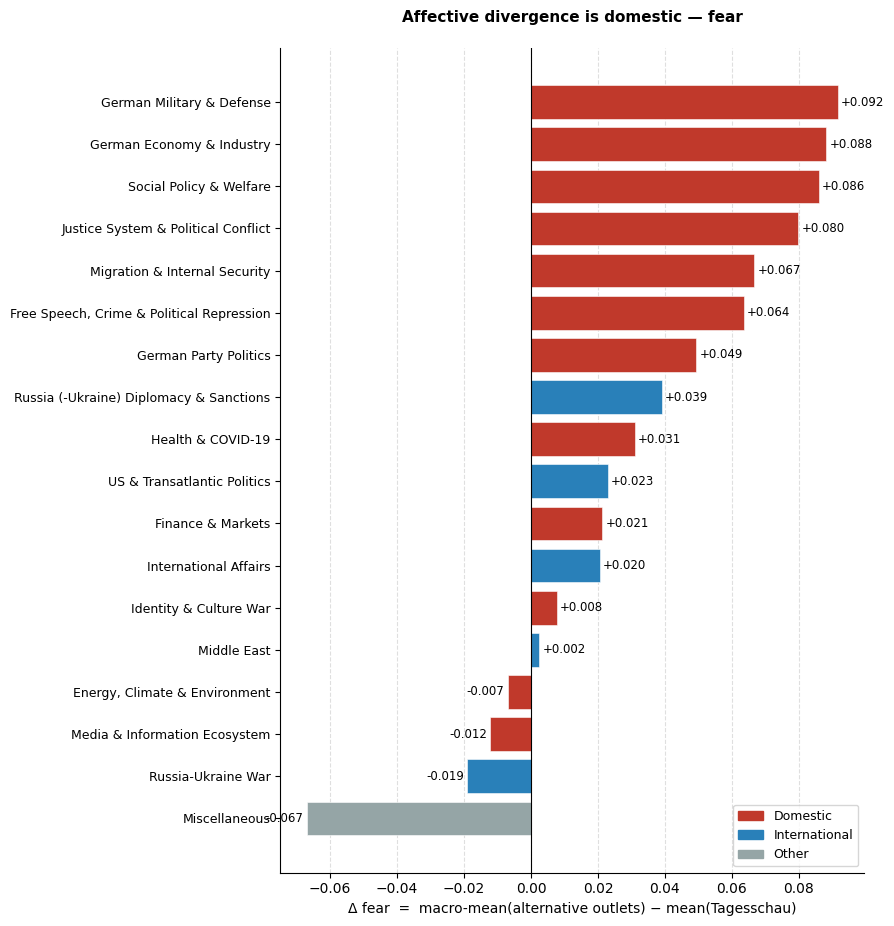

In [56]:
# ── Δ fear per cluster: mean(alternative outlets) − mean(Tagesschau) ────────
# Bars coloured by topic geography: Domestic / International / Other
# Alternative-outlet side uses macro-mean (avg of per-outlet means) to avoid
# size-imbalance bias across outlets.


def _geo(cluster):
    if cluster in DOMESTIC:      return "Domestic"
    if cluster in INTERNATIONAL: return "International"
    return "Other"


min_n = 10

tg  = df[df["source"] == "Tagesschau"]
alt = df[df["source"] != "Tagesschau"]

# Tagesschau: grand mean per cluster
tg_means = tg.groupby("Manual Cluster Label")[fear_col].mean()

# Alternative outlets: macro-mean (avg of per-outlet means per cluster)
alt_macro = (
    alt.groupby(["Manual Cluster Label", "source"])[fear_col]
    .mean()
    .groupby("Manual Cluster Label")
    .mean()
)

# Keep clusters with enough articles in BOTH groups
tg_n  = tg.groupby("Manual Cluster Label").size()
alt_n = alt.groupby("Manual Cluster Label").size()
keep  = tg_n.index.intersection(alt_n.index).intersection(alt_macro.index)
keep  = keep[(tg_n[keep] >= min_n) & (alt_n[keep] >= min_n)]

delta = (alt_macro[keep] - tg_means[keep]).sort_values(ascending=True)

colors = [GEO_COLOR[_geo(c)] for c in delta.index]

fig, ax = plt.subplots(figsize=(9, max(5, len(delta) * 0.52)))

bars = ax.barh(delta.index, delta.values, color=colors, edgecolor="white", linewidth=0.4)

for bar, val in zip(bars, delta.values):
    sign  = "+" if val >= 0 else ""
    x_pos = val + (0.001 if val >= 0 else -0.001)
    ha    = "left" if val >= 0 else "right"
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f"{sign}{val:.3f}", va="center", ha=ha, fontsize=8.5)

ax.axvline(0, color="black", linewidth=0.8)
ax.xaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.set_xlabel("Δ fear  =  macro-mean(alternative outlets) − mean(Tagesschau)", fontsize=10)
ax.set_title(
    "Affective divergence is domestic — fear\n",
    fontsize=11, fontweight="bold",
)
ax.tick_params(axis="y", labelsize=9)
ax.spines[["top", "right"]].set_visible(False)

legend_handles = [Patch(color=c, label=l) for l, c in GEO_COLOR.items()]
ax.legend(handles=legend_handles, loc="lower right", frameon=True, fontsize=9)

plt.tight_layout()
plt.show()


In [57]:
# ── Summary: Δ fear domestic vs international — alternative outlets vs Tagesschau
# Uses DOMESTIC / INTERNATIONAL sets defined in the cell above.

def _geo(cluster):
    if cluster in DOMESTIC:      return "Domestic"
    if cluster in INTERNATIONAL: return "International"
    return "Other"

df["geo"] = df["Manual Cluster Label"].map(_geo)

tg  = df[df["source"] == "Tagesschau"]
alt = df[df["source"] != "Tagesschau"]

results = {}
for geo in ("Domestic", "International"):
    tg_mean  = tg[tg["geo"]  == geo][fear_col].mean()
    # macro-mean: average of per-outlet means (corrects for outlet size)
    alt_macro = (
        alt[alt["geo"] == geo]
        .groupby("source")[fear_col].mean()
        .mean()
    )
    delta = alt_macro - tg_mean
    results[geo] = {"Tagesschau": tg_mean, "Alt (macro)": alt_macro, "Δ": delta}
    print(f"{geo:15s}  →  Tagesschau: {tg_mean:.4f}  |  Alt outlets: {alt_macro:.4f}  |  Δ = {delta:+.4f}")


Domestic         →  Tagesschau: 0.2190  |  Alt outlets: 0.2560  |  Δ = +0.0371
International    →  Tagesschau: 0.2697  |  Alt outlets: 0.2711  |  Δ = +0.0013


Outlet                    Δ_dom sig_dom   Δ_intl sig_intl  diff (dom−intl)
---------------------------------------------------------------------------
Deutschlandkurier       +0.0632***   -0.0136              +0.0768
RT_de                   +0.0011      -0.0510***           +0.0520
Compact                 +0.1057***   +0.0697***           +0.0360
Tichys_Einblick         +0.0407***   +0.0080              +0.0327
Antispiegel             -0.0335      -0.0585***           +0.0250
Nius                    +0.0453***   +0.0534***           -0.0081


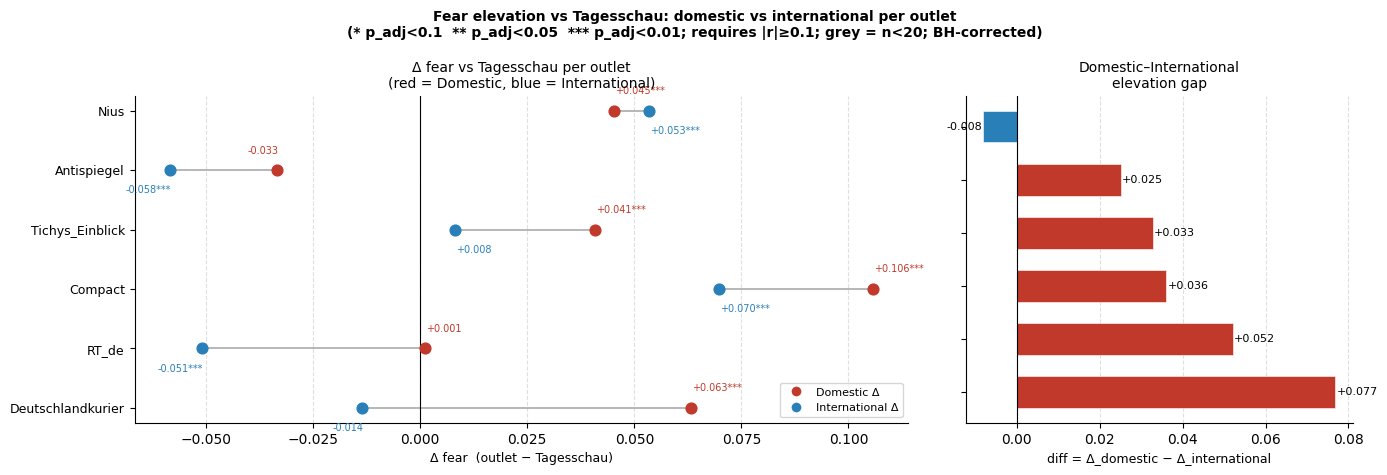

In [58]:
# ── Per-outlet: domestic vs international elevation gap vs Tagesschau (fear) ─────
# For each outlet: Δ_domestic and Δ_international (vs Tagesschau), tested with MWU + BH.
# Key metric: diff = Δ_domestic − Δ_international
#   positive → outlet elevates fear MORE on domestic than on international topics

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import numpy as np

MIN_N        = 20
EFFECT_R_MIN = 0.10

df["geo"] = df["Manual Cluster Label"].map(_geo)
tg_all  = df[df["source"] == "Tagesschau"]
outlets = sorted(df[df["source"] != "Tagesschau"]["source"].unique())

records = []
for geo in ("Domestic", "International"):
    tg_vals = tg_all[tg_all["geo"] == geo][fear_col].values
    for outlet in outlets:
        alt_vals = df[(df["source"] == outlet) & (df["geo"] == geo)][fear_col].values
        n1, n2   = len(alt_vals), len(tg_vals)
        base = dict(geo=geo, outlet=outlet, n_outlet=n1, n_tg=n2,
                    mean_outlet=float(np.mean(alt_vals)) if n1 > 0 else float("nan"),
                    mean_tg=float(np.mean(tg_vals))     if n2 > 0 else float("nan"))
        if n1 < MIN_N or n2 < MIN_N:
            records.append({**base, "delta": float("nan"), "r": float("nan"),
                             "p_raw": float("nan"), "excluded": True})
            continue
        U, p_raw = mannwhitneyu(alt_vals, tg_vals, alternative="two-sided")
        r = (2 * U) / (n1 * n2) - 1
        records.append({**base, "delta": base["mean_outlet"] - base["mean_tg"],
                         "r": r, "p_raw": p_raw, "excluded": False})

res   = pd.DataFrame(records)
valid = res[~res["excluded"]].copy()

reject, p_adj, _, _ = multipletests(valid["p_raw"].values, alpha=0.05, method="fdr_bh")
valid["p_adjusted"]   = p_adj
valid["p_adj_masked"] = valid["p_adjusted"].where(valid["r"].abs() >= EFFECT_R_MIN, other=1.0)

def _sig(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.1:  return "*"
    return ""

valid["marker"] = valid["p_adj_masked"].apply(_sig)

wide = valid.pivot(index="outlet", columns="geo", values=["delta", "marker", "r"])
wide.columns = ["_".join(c) for c in wide.columns]
wide["diff"] = wide.get("delta_Domestic", float("nan")) - wide.get("delta_International", float("nan"))
wide = wide.sort_values("diff", ascending=False)

print(f"{'Outlet':<22} {'Δ_dom':>8} {'sig_dom':>7} {'Δ_intl':>8} {'sig_intl':>8} {'diff (dom−intl)':>16}")
print("-" * 75)
for outlet, row in wide.iterrows():
    d_dom  = row.get("delta_Domestic",      float("nan"))
    m_dom  = row.get("marker_Domestic",     "")
    d_int  = row.get("delta_International", float("nan"))
    m_int  = row.get("marker_International","")
    diff   = row["diff"]
    d_dom_s  = f"{d_dom:+.4f}"  if not pd.isna(d_dom)  else "  excl."
    d_int_s  = f"{d_int:+.4f}"  if not pd.isna(d_int)  else "  excl."
    diff_s   = f"{diff:+.4f}"   if not pd.isna(diff)   else "    n/a"
    print(f"{outlet:<22} {d_dom_s:>8}{m_dom:<3}  {d_int_s:>8}{m_int:<3}  {diff_s:>16}")

outlet_order = wide.index.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, max(4, len(outlet_order) * 0.55 + 1.5)),
                                gridspec_kw={"width_ratios": [2, 1]})

DOM_COLOR  = "#c0392b"
INTL_COLOR = "#2980b9"

for i, outlet in enumerate(outlet_order):
    row   = wide.loc[outlet]
    d_dom = row.get("delta_Domestic",      float("nan"))
    d_int = row.get("delta_International", float("nan"))
    m_dom = row.get("marker_Domestic",     "")
    m_int = row.get("marker_International","")

    if not (pd.isna(d_dom) or pd.isna(d_int)):
        ax1.plot([d_dom, d_int], [i, i], color="#aaaaaa", linewidth=1.2, zorder=1)

    if not pd.isna(d_dom):
        ax1.scatter(d_dom, i, color=DOM_COLOR,  s=60, zorder=3)
        ax1.text(d_dom + 0.0003, i + 0.25, f"{d_dom:+.3f}{m_dom}", fontsize=7,
                 color=DOM_COLOR,  ha="left" if d_dom >= 0 else "right", va="bottom")
    if not pd.isna(d_int):
        ax1.scatter(d_int, i, color=INTL_COLOR, s=60, zorder=3)
        ax1.text(d_int + 0.0003, i - 0.25, f"{d_int:+.3f}{m_int}", fontsize=7,
                 color=INTL_COLOR, ha="left" if d_int >= 0 else "right", va="top")

ax1.axvline(0, color="black", linewidth=0.8)
ax1.set_yticks(range(len(outlet_order)))
ax1.set_yticklabels(outlet_order, fontsize=9)
ax1.set_xlabel("Δ fear  (outlet − Tagesschau)", fontsize=9)
ax1.set_title("Δ fear vs Tagesschau per outlet\n(red = Domestic, blue = International)", fontsize=10)
ax1.xaxis.grid(True, linestyle="--", alpha=0.4)
ax1.set_axisbelow(True)
ax1.spines[["top", "right"]].set_visible(False)

from matplotlib.lines import Line2D
ax1.legend(handles=[
    Line2D([0],[0], marker="o", color="w", markerfacecolor=DOM_COLOR,  markersize=8, label="Domestic Δ"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor=INTL_COLOR, markersize=8, label="International Δ"),
], fontsize=8, frameon=True, loc="lower right")

diff_vals  = [wide.loc[o, "diff"] if not pd.isna(wide.loc[o, "diff"]) else 0 for o in outlet_order]
bar_colors = ["#c0392b" if v > 0 else "#2980b9" for v in diff_vals]
ax2.barh(range(len(outlet_order)), diff_vals, color=bar_colors,
         edgecolor="white", linewidth=0.4, height=0.6)
for i, (v, outlet) in enumerate(zip(diff_vals, outlet_order)):
    if pd.isna(wide.loc[outlet, "diff"]): continue
    ax2.text(v + (0.0003 if v >= 0 else -0.0003), i,
             f"{v:+.3f}", va="center", ha="left" if v >= 0 else "right", fontsize=8)
ax2.axvline(0, color="black", linewidth=0.8)
ax2.set_yticks(range(len(outlet_order)))
ax2.set_yticklabels([])
ax2.set_xlabel("diff = Δ_domestic − Δ_international", fontsize=9)
ax2.set_title("Domestic–International\nelevation gap", fontsize=10)
ax2.xaxis.grid(True, linestyle="--", alpha=0.4)
ax2.set_axisbelow(True)
ax2.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"Fear elevation vs Tagesschau: domestic vs international per outlet\n"
    f"(* p_adj<0.1  ** p_adj<0.05  *** p_adj<0.01; requires |r|≥{EFFECT_R_MIN}; grey = n<{MIN_N}; BH-corrected)",
    fontsize=10, fontweight="bold",
)
plt.tight_layout()
plt.show()


### Cluster & outlet level

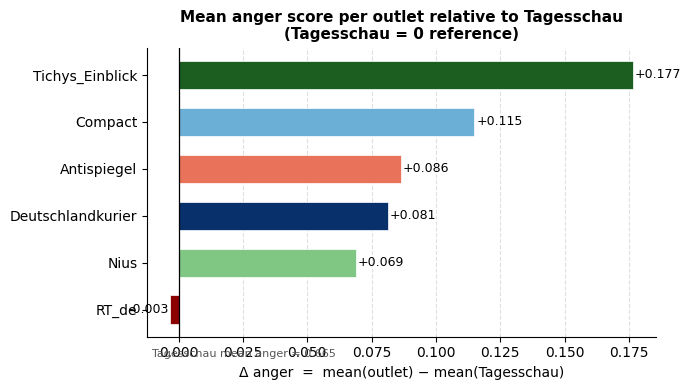

In [ ]:
# ── Δ anger per outlet vs Tagesschau (no topic breakdown) ───────────────────

OUTLET_COLORS = {
    "RT_de":              "#8B0000",   # dark red
    "Antispiegel":        "#E8735A",   # light red
    "Deutschlandkurier":  "#08306B",   # dark blue
    "Compact":            "#6BAED6",   # light blue
    "Tichys_Einblick":    "#1B5E20",   # dark green
    "Nius":               "#81C784",   # light green
}

tg_anger = df.loc[df["source"] == "Tagesschau", anger_col].mean()

outlet_means = (
    df[df["source"].isin(OUTLET_COLORS)]
    .groupby("source")[anger_col]
    .mean()
)
delta = (outlet_means - tg_anger).sort_values(ascending=True)

colors = [OUTLET_COLORS[s] for s in delta.index]

fig, ax = plt.subplots(figsize=(7, max(4, len(delta) * 0.65)))

bars = ax.barh(delta.index, delta.values, color=colors,
               edgecolor="white", linewidth=0.5, height=0.6)

for bar, val in zip(bars, delta.values):
    sign  = "+" if val >= 0 else ""
    x_pos = val + 0.0008 if val >= 0 else val - 0.0008
    ha    = "left" if val >= 0 else "right"
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f"{sign}{val:.3f}", va="center", ha=ha, fontsize=9)

ax.axvline(0, color="black", linewidth=0.9)
ax.xaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.set_xlabel("Δ anger  =  mean(outlet) − mean(Tagesschau)", fontsize=10)
ax.set_title(
    "Mean anger score per outlet relative to Tagesschau\n"
    "(Tagesschau = 0 reference)",
    fontsize=11, fontweight="bold",
)
ax.tick_params(axis="y", labelsize=10)
ax.spines[["top", "right"]].set_visible(False)

# Annotate Tagesschau mean for reference
ax.text(0.01, -0.07, f"Tagesschau mean anger = {tg_anger:.3f}",
        transform=ax.transAxes, fontsize=8, color="#555555")

plt.tight_layout()
plt.show()
